# EEEM068 - Sagittal ACL ViT-Small from Scratch - Part 4

**Scope:** Training loop, TensorBoard notes, and training curves

**Source notebook:** `sagittal_acl_scratch.ipynb`

**Notes**
- This notebook is a split component of the original final notebook.
- Some setup cells are intentionally repeated so each part is easier to understand in isolation.
- If you want to run the full pipeline end-to-end, use the original notebook or follow the README in sequence.

# EEEM068 — Knee MRI ACL Classification: ViT-Small from Scratch

## Key Constraints
- **No pretrained weights** — full training from scratch on MRNet only
- **Sagittal plane only** — binary ACL classification (positive / negative)
- **~21M parameters** — ViT-Small/16 architecture (embed_dim=384, 12 blocks, 6 heads)
- All regularisation is tuned for a small medical dataset (≈1130 training scans)

## Why training from scratch is hard here
ViT-Small normally needs ImageNet-scale data. With only 1130 scans, we compensate with:
1. **Strong augmentation** — aggressive random affine, H-flip, colour jitter, Gaussian blur
2. **MixUp + CutMix** — both applied stochastically for better generalisation
3. **Stochastic depth (DropPath)** — 0.15 rate, prevents transformer co-adaptation
4. **Heavy head dropout** — 0.5 / 0.25 in the MLP head
5. **Label smoothing** — 0.1 for binary BCE
6. **Focal loss** — focuses learning on hard/rare positive ACL cases (γ=2, α=0.75)
7. **Warmup + cosine decay** — 10-epoch warmup, essential for ViT from scratch
8. **Weight decay 0.05** — strong L2, following MAE/DINO from-scratch recipes
9. **WeightedRandomSampler** — ACL is only 18% positive, needs oversampling
10. **Gradient clipping** — max norm 1.0

## Parameter count breakdown
| Component | Parameters |
|---|---|
| Patch embedding (16×16 → 384) | 295,296 |
| Positional embedding (197 × 384) | 75,648 |
| CLS token | 384 |
| 12 × Transformer blocks | 21,233,664 |
| Layer norm | 768 |
| Classification head | 50,689 |
| **Total** | **~21.66M** |


## Section 1 — Install & Imports

In [48]:
!pip install -q timm kagglehub

In [49]:
import os, gc, math, random, warnings
from pathlib import Path
from collections import deque
from io import BytesIO
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter

import timm

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report,
    balanced_accuracy_score
)

warnings.filterwarnings("ignore")

# Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.11.0+cu130
timm     : 1.0.27
CUDA     : True
GPU      : NVIDIA RTX 4000 Ada Generation


## Section 2 — Configuration

All hyperparameters in one place. Key differences from a pretrained setup:

- `WARMUP_EPOCHS = 10` — ViT from scratch needs a long warmup to stabilise attention weights
- `EPOCHS = 120` — needs many more epochs without ImageNet initialisation
- `WEIGHT_DECAY = 0.05` — strong L2, follows MAE/DINO from-scratch training recipes
- `DROP_PATH_RATE = 0.15` — slightly higher stochastic depth since no pretrained regularisation
- `BASE_LR = 1e-3` — from-scratch ViT uses higher base LR than fine-tuning
- `MIN_LR = 1e-6` — cosine decay floor
- **No progressive unfreezing** — entire model trains from epoch 1

In [50]:
class CFG:
    # ── Paths ──────────────────────────────────────────────────────────────
    OUT_DIR          = Path("./mrnet_scratch_acl")
    CHECKPOINT_PATH  = str(OUT_DIR / "best_vit_scratch_acl.pth")
    TENSORBOARD_DIR  = str(OUT_DIR / "tb_scratch_acl")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # ── Task ───────────────────────────────────────────────────────────────
    # Binary: ACL tear (positive=1) vs no ACL tear (negative=0)
    # Sagittal plane only
    PLANE       = "sagittal"
    LABEL       = "acl"
    NUM_CLASSES = 1  # binary sigmoid output

    # ── Model ──────────────────────────────────────────────────────────────
    IMAGE_SIZE     = 224
    MODEL_NAME     = "vit_small_patch16_224"  # 21.66M params
    DROP_PATH_RATE = 0.15  # higher than fine-tune (0.10) for scratch

    # ── MRI slice selection ────────────────────────────────────────────────
    TOP_K_SLICES = 8   # select from top-8 high-variance slices
    N_CHANNELS   = 3   # stack 3 of them as R,G,B

    # ── Training ───────────────────────────────────────────────────────────
    BATCH_SIZE  = 8     # reduced for GPU memory; use GRAD_ACCUM to keep effective batch=16
    GRAD_ACCUM  = 2     # gradient accumulation steps → effective batch = BATCH_SIZE * GRAD_ACCUM
    EPOCHS      = 120
    MIN_EPOCHS  = 40
    PATIENCE    = 20
    NUM_WORKERS = 0     # 0 = main process only — avoids pin_memory OOM on shared/limited GPUs
    PIN_MEMORY  = False # pin_memory was the direct cause of AcceleratorError; keep False
    SEED        = 42

    # ── Learning rate (from-scratch recipe) ────────────────────────────────
    # Base LR scales with batch size: base_lr * (batch_size / 256)
    # base_lr = 1e-3 is the standard ViT from-scratch value
    BASE_LR      = 1e-3 * (BATCH_SIZE / 256)  # ~6.25e-5 for batch=16
    HEAD_LR      = 5e-4   # head gets a slightly higher LR
    MIN_LR       = 1e-6
    WEIGHT_DECAY = 0.05   # strong L2, MAE-style
    WARMUP_EPOCHS = 10    # long warmup for from-scratch ViT

    # ── Regularisation ─────────────────────────────────────────────────────
    DROPOUT_HEAD1  = 0.50   # heavier dropout for small dataset
    DROPOUT_HEAD2  = 0.25
    LABEL_SMOOTH   = 0.10   # 0.10 for binary (0→0.05, 1→0.95)

    # ── MixUp & CutMix ─────────────────────────────────────────────────────
    MIXUP_ALPHA    = 0.4    # Beta(0.4, 0.4) for MixUp
    CUTMIX_ALPHA   = 1.0    # Beta(1.0, 1.0) for CutMix
    MIXUP_PROB     = 0.5    # probability of applying either augmentation
    MIXUP_CUTMIX_SPLIT = 0.5  # 50/50 split between MixUp and CutMix

    # ── Focal Loss ─────────────────────────────────────────────────────────
    FOCAL_GAMMA = 2.0   # focusing parameter: 2.0 is standard
    FOCAL_ALPHA = 0.75  # weight for positive class (ACL positive is rare)

    # ── TTA ────────────────────────────────────────────────────────────────
    TTA_N = 8           # test-time augmentation passes

    # ── Threshold ──────────────────────────────────────────────────────────
    # Optimised on validation set after training
    THRESHOLD = 0.5     # updated by find_optimal_threshold()

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("CFG loaded")
print(f"  Task         : {CFG.LABEL.upper()} binary (sagittal only)")
print(f"  Pretrained   : NONE — from scratch")
print(f"  Device       : {CFG.DEVICE}")
print(f"  Base LR      : {CFG.BASE_LR:.2e}")
print(f"  Weight decay : {CFG.WEIGHT_DECAY}")
print(f"  Warmup       : {CFG.WARMUP_EPOCHS} epochs")
print(f"  Epochs       : {CFG.EPOCHS}")

CFG loaded
  Task         : ACL binary (sagittal only)
  Pretrained   : NONE — from scratch
  Device       : cuda
  Base LR      : 3.13e-05
  Weight decay : 0.05
  Warmup       : 10 epochs
  Epochs       : 120


## Section 3 — Dataset Download & Labels

In [51]:
# ═══════════════════════════════════════════════════════════════════════════
# DATASET SETUP — three options, use whichever fits your environment
# ═══════════════════════════════════════════════════════════════════════════

# ── Option A: Already extracted manually ──────────────────────────────────
# If you downloaded and unzipped the dataset yourself, just set the path here
# and skip everything else. The folder must contain train/, valid/, and the
# six CSV label files.
#
# MANUAL_ROOT = "/path/to/MRNet-v1.0"   # ← set this
# CFG.ROOT = Path(MANUAL_ROOT)
# assert CFG.ROOT.exists(), f"Dataset not found: {CFG.ROOT}"
# print(f"✓ Dataset at: {CFG.ROOT}")


# ── Option B: Streaming — extract ONLY sagittal + labels (saves ~5 GB) ────
# Avoids the 'No space left on device' error by extracting only the files
# we actually need (sagittal plane + CSV labels) from the zip.
# The full zip is ~6 GB but sagittal + labels is only ~2 GB.

import zipfile, glob

# Find the already-downloaded zip in kagglehub cache
# kagglehub stores downloads at ~/.cache/kagglehub/datasets/cjinny/mrnet-v1/
CACHE_GLOB = os.path.expanduser(
    "~/.cache/kagglehub/datasets/cjinny/mrnet-v1/versions/*/mrnet-v1.zip"
)
zip_candidates = glob.glob(CACHE_GLOB)

# Also check the raw download path if kagglehub used a different layout
if not zip_candidates:
    CACHE_GLOB2 = os.path.expanduser(
        "~/.cache/kagglehub/datasets/cjinny/mrnet-v1/**/*.zip"
    )
    zip_candidates = glob.glob(CACHE_GLOB2, recursive=True)

EXTRACT_DIR = Path(os.path.expanduser("~/Downloads/AML/mrnet_sagittal_only"))
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

if zip_candidates:
    zip_path = zip_candidates[0]
    print(f"Found zip: {zip_path}")
    print(f"Extracting sagittal + labels only → {EXTRACT_DIR}")

    with zipfile.ZipFile(zip_path, 'r') as z:
        all_names = z.namelist()
        # Keep only sagittal .npy files and all .csv label files
        to_extract = [
            n for n in all_names
            if '/sagittal/' in n or n.endswith('.csv')
        ]
        print(f"  Total files in zip : {len(all_names)}")
        print(f"  Files to extract   : {len(to_extract)} (sagittal + csv)")

        for i, name in enumerate(to_extract):
            z.extract(name, EXTRACT_DIR)
            if (i + 1) % 200 == 0:
                print(f"  Extracted {i+1}/{len(to_extract)}...", end="\r")

    print(f"\n✓ Extraction complete")
    CFG.ROOT = EXTRACT_DIR / "MRNet-v1.0"

else:
    # ── Option C: Download fresh with kagglehub to a custom output directory
    # This lets you point extraction at a drive/partition with more space.
    print("No cached zip found — downloading via kagglehub...")
    print("Tip: if you get 'No space left', manually download the zip from:")
    print("  https://www.kaggle.com/datasets/cjinny/mrnet-v1")
    print("and set MANUAL_ROOT in Option A above.")

    import kagglehub
    # Set output_dir to a path with enough space
    dl_path  = kagglehub.dataset_download(
        "cjinny/mrnet-v1",
        output_dir=str(EXTRACT_DIR)  # extract here instead of cache
    )
    CFG.ROOT = Path(dl_path) / "MRNet-v1.0"

assert CFG.ROOT.exists(), (
    f"Dataset root not found: {CFG.ROOT}\n"
    f"Please set MANUAL_ROOT in Option A and uncomment those lines."
)
print(f"✓ Dataset root: {CFG.ROOT}")

# Verify the structure we need exists
for split in ['train', 'valid']:
    sag_dir = CFG.ROOT / split / 'sagittal'
    csv_file = CFG.ROOT / f'{split}-acl.csv'
    assert sag_dir.exists(), f"Missing: {sag_dir}"
    assert csv_file.exists(), f"Missing: {csv_file}"
    n_npy = len(list(sag_dir.glob('*.npy')))
    print(f"  {split}/sagittal/ : {n_npy} .npy files  |  {split}-acl.csv ✓")

No cached zip found — downloading via kagglehub...
Tip: if you get 'No space left', manually download the zip from:
  https://www.kaggle.com/datasets/cjinny/mrnet-v1
and set MANUAL_ROOT in Option A above.
✓ Dataset root: /user/HS402/lt01109/Downloads/AML/mrnet_sagittal_only/MRNet-v1.0
  train/sagittal/ : 1130 .npy files  |  train-acl.csv ✓
  valid/sagittal/ : 120 .npy files  |  valid-acl.csv ✓


In [52]:
def load_labels(root, split):
    """
    Load labels for binary ACL classification.
    Returns a DataFrame with columns: id, acl, sagittal_path, label
    """
    acl_df = pd.read_csv(root / f"{split}-acl.csv", header=None, names=["id", "acl"])
    acl_df["id"] = acl_df["id"].astype(str).str.zfill(4)
    acl_df["sagittal_path"] = acl_df["id"].apply(
        lambda x: str(root / split / "sagittal" / f"{x}.npy")
    )
    acl_df["label"] = acl_df["acl"].astype(float)
    return acl_df

train_df = load_labels(CFG.ROOT, "train")
valid_df = load_labels(CFG.ROOT, "valid")

n_pos_train = int(train_df["label"].sum())
n_pos_valid = int(valid_df["label"].sum())

print(f"Train : {len(train_df)} scans  |  ACL+ = {n_pos_train} ({100*n_pos_train/len(train_df):.1f}%)  ACL- = {len(train_df)-n_pos_train}")
print(f"Valid : {len(valid_df)} scans  |  ACL+ = {n_pos_valid} ({100*n_pos_valid/len(valid_df):.1f}%)  ACL- = {len(valid_df)-n_pos_valid}")
print(f"Class imbalance ratio: {(len(train_df)-n_pos_train)/n_pos_train:.2f}:1 (neg:pos)")

Train : 1130 scans  |  ACL+ = 208 (18.4%)  ACL- = 922
Valid : 120 scans  |  ACL+ = 54 (45.0%)  ACL- = 66
Class imbalance ratio: 4.43:1 (neg:pos)


## Section 5 — Preprocessing & Dataset

**Slice selection strategy:**
MRI volumes have variable depth (typically 20–35 slices for sagittal). We rank all slices by pixel variance — high variance means structural content rather than blank background or artifact. The top-K are selected and 3 are chosen spread evenly to cover anterior, mid, and posterior knee regions. These become the R, G, B channels.

**Dataset-specific normalisation (not ImageNet):**
Since we train from scratch, we compute MRNet-specific mean/std from a random sample of training volumes rather than using ImageNet statistics. This is critical — ImageNet stats are wrong for MRI data.

**Training augmentation (stronger for from-scratch):**
- Random rotation ±20°
- Random translation ±12% X and Y
- Random scaling 80–120%
- Random horizontal flip
- Colour jitter (brightness, contrast)
- Random Gaussian blur
- Random erasing (simulates MRI artefacts)

In [54]:
def compute_dataset_stats(df, n_samples=150, top_k=8, n_ch=3):
    """
    Compute mean and std from MRNet training data instead of using ImageNet stats.
    Samples n_samples volumes and estimates statistics per channel.
    This is important for from-scratch training — ImageNet stats are incorrect for MRI.
    """
    print(f"Computing dataset statistics from {n_samples} random training scans...")
    sample_df = df.sample(min(n_samples, len(df)), random_state=42)
    all_pixels = [[] for _ in range(n_ch)]

    for _, row in sample_df.iterrows():
        vol = np.load(row["sagittal_path"], mmap_mode="r")
        D   = vol.shape[0]
        var = np.var(vol.reshape(D, -1), axis=1)
        topk = np.sort(np.argsort(var)[-min(top_k, D):])
        chosen = topk[np.linspace(0, len(topk)-1, n_ch, dtype=int)]
        for ch, idx in enumerate(chosen):
            s = vol[idx].astype(np.float32)
            lo, hi = s.min(), s.max()
            s = (s - lo) / (hi - lo + 1e-8)  # [0, 1]
            all_pixels[ch].append(s.flatten())

    means = [np.concatenate(c).mean() for c in all_pixels]
    stds  = [np.concatenate(c).std()  for c in all_pixels]
    print(f"  MRNet mean : {[f'{m:.4f}' for m in means]}")
    print(f"  MRNet std  : {[f'{s:.4f}' for s in stds]}")
    return means, stds

MRNET_MEAN, MRNET_STD = compute_dataset_stats(train_df)

Computing dataset statistics from 150 random training scans...
  MRNet mean : ['0.2190', '0.2299', '0.2180']
  MRNet std  : ['0.1992', '0.1989', '0.1983']


In [55]:
def select_topk_variance_slices(volume, top_k=8, n_out=3):
    """Rank slices by pixel variance, select n_out spread evenly across the top-K."""
    D    = volume.shape[0]
    var  = np.var(volume.reshape(D, -1), axis=1)
    topk = np.sort(np.argsort(var)[-min(top_k, D):])
    n_out = min(n_out, len(topk))
    chosen = topk[np.linspace(0, len(topk)-1, n_out, dtype=int)]
    if len(chosen) < n_out:
        chosen = np.pad(chosen, (0, n_out - len(chosen)), mode="edge")
    return volume[chosen]


def volume_to_rgb(volume, top_k=8, n_ch=3):
    """3D MRI volume → pseudo-RGB PIL image using per-slice min-max normalisation."""
    slices = select_topk_variance_slices(volume, top_k=top_k, n_out=n_ch)
    channels = []
    for s in slices:
        s = s.astype(np.float32)
        lo, hi = s.min(), s.max()
        s = (s - lo) / (hi - lo + 1e-8)
        channels.append((s * 255).clip(0, 255).astype(np.uint8))
    return Image.fromarray(np.stack(channels, axis=-1))


# ── Transforms ─────────────────────────────────────────────────────────────
# From scratch needs stronger augmentation than fine-tuning
train_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.RandomAffine(
        degrees=20,
        translate=(0.12, 0.12),
        scale=(0.80, 1.20),
        fill=0
    ),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=MRNET_MEAN, std=MRNET_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.10), ratio=(0.3, 3.3)),
])

tta_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.92, 1.08), fill=0),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=MRNET_MEAN, std=MRNET_STD),
])

valid_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MRNET_MEAN, std=MRNET_STD),
])

print("✓ Transforms defined (MRNet normalisation, not ImageNet)")

✓ Transforms defined (MRNet normalisation, not ImageNet)


In [56]:
class MRNetACLDataset(Dataset):
    """
    Binary ACL classification from sagittal MRI volumes.
    Each volume is converted to a pseudo-RGB image using the top-K
    high-variance slices.
    """
    def __init__(self, df, transforms=None, top_k=8, n_ch=3):
        self.df         = df.reset_index(drop=True)
        self.transforms = transforms
        self.top_k      = top_k
        self.n_ch       = n_ch

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        vol = np.load(row["sagittal_path"], mmap_mode="r")
        img = volume_to_rgb(vol, top_k=self.top_k, n_ch=self.n_ch)
        if self.transforms:
            img = self.transforms(img)
        label = torch.tensor([row["label"]], dtype=torch.float32)  # shape (1,)
        return img, label, row["id"]

# Quick sanity check
ds_check = MRNetACLDataset(train_df.head(3), transforms=train_tfm)
img, lbl, eid = ds_check[0]
print(f"Image tensor : {tuple(img.shape)}")
print(f"Label        : {lbl}  (ACL {'positive' if lbl[0]==1 else 'negative'})")
print(f"Exam ID      : {eid}")

Image tensor : (3, 224, 224)
Label        : tensor([0.])  (ACL negative)
Exam ID      : 0000


## Section 6 — Class Imbalance Handling

ACL tear prevalence is ~18% (208/1130 training scans). Without correction, the model reaches 82% accuracy by always predicting negative. Two complementary strategies:

1. **WeightedRandomSampler** — oversample ACL+ scans at the DataLoader level so each batch sees roughly equal positive/negative examples
2. **Focal Loss with alpha** — `alpha=0.75` weights the positive class loss by 3x relative to negative class, compounding the sampler effect for hard examples

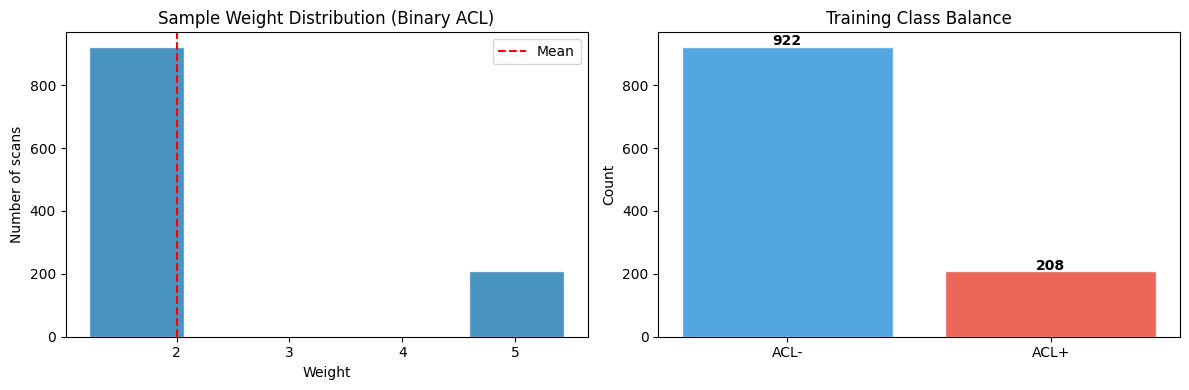

Weight for ACL+ : 5.43
Weight for ACL- : 1.23


In [57]:
def compute_sample_weights_binary(df, label_col="label"):
    """Inverse-frequency weights for binary WeightedRandomSampler."""
    pos_rate = df[label_col].mean()
    neg_rate = 1.0 - pos_rate
    weights  = df[label_col].apply(
        lambda x: 1.0 / pos_rate if x == 1 else 1.0 / neg_rate
    ).values
    return torch.tensor(weights, dtype=torch.float64)

sample_weights = compute_sample_weights_binary(train_df)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_df),
    replacement=True
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(sample_weights.numpy(), bins=5, color="#2980B9", edgecolor="white", alpha=0.85)
ax1.axvline(sample_weights.mean().item(), color="red", linestyle="--", label="Mean")
ax1.set_title("Sample Weight Distribution (Binary ACL)")
ax1.set_xlabel("Weight"); ax1.set_ylabel("Number of scans"); ax1.legend()

neg_count = (train_df["label"]==0).sum()
pos_count = (train_df["label"]==1).sum()
ax2.bar(["ACL-", "ACL+"], [neg_count, pos_count],
        color=["#3498DB", "#E74C3C"], alpha=0.85, edgecolor="white")
ax2.set_title("Training Class Balance")
ax2.set_ylabel("Count")
for i, v in enumerate([neg_count, pos_count]):
    ax2.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(CFG.OUT_DIR / "class_balance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Weight for ACL+ : {sample_weights[train_df['label']==1][0]:.2f}")
print(f"Weight for ACL- : {sample_weights[train_df['label']==0][0]:.2f}")

## Section 7 — DataLoaders

In [58]:
# Clear any leftover GPU memory before building loaders
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    free, total = torch.cuda.mem_get_info()
    print(f"GPU memory: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total")

train_ds = MRNetACLDataset(train_df, transforms=train_tfm,
                            top_k=CFG.TOP_K_SLICES, n_ch=CFG.N_CHANNELS)
valid_ds = MRNetACLDataset(valid_df, transforms=valid_tfm,
                            top_k=CFG.TOP_K_SLICES, n_ch=CFG.N_CHANNELS)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    sampler=sampler,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=CFG.PIN_MEMORY,  # False — avoids AcceleratorError on shared GPUs
    drop_last=True
)
valid_loader = DataLoader(
    valid_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=CFG.PIN_MEMORY,
)

eff_batch = CFG.BATCH_SIZE * CFG.GRAD_ACCUM
print(f"Train : {len(train_ds)} scans  →  {len(train_loader)} batches/epoch")
print(f"Valid : {len(valid_ds)} scans  →  {len(valid_loader)} batches/epoch")
print(f"Batch : {CFG.BATCH_SIZE} × {CFG.GRAD_ACCUM} grad accum = {eff_batch} effective")
img_b, lbl_b, _ = next(iter(train_loader))
print(f"Batch shape : {tuple(img_b.shape)},  Labels: {lbl_b.squeeze()[:8].tolist()}")

GPU memory: 19.4 GB free / 21.0 GB total
Train : 1130 scans  →  141 batches/epoch
Valid : 120 scans  →  15 batches/epoch
Batch : 8 × 2 grad accum = 16 effective
Batch shape : (8, 3, 224, 224),  Labels: [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [59]:
# Kill all GPU state from previous runs
import torch, gc

# Delete any model/optimizer variables still in memory
for var in ['model', 'optimizer', 'scheduler', 'train_loader', 'valid_loader']:
    if var in dir():
        del globals()[var]

gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
print("GPU cleared")

GPU cleared


## Section 8 — Model: ViT-Small from Scratch (~21.66M params)

Architecture: `vit_small_patch16_224` via timm.
- 12 Transformer blocks
- embed_dim = 384
- 6 attention heads, head_dim = 64
- patch_size = 16 → 14×14 = 196 patches + 1 CLS = 197 tokens
- `pretrained=False` — random initialisation, no ImageNet weights

**Weight initialisation (critical for from-scratch ViT):**
- Linear layers: truncated normal (σ=0.02), following ViT paper
- LayerNorm: weight=1, bias=0
- QKV bias: zeros
- Positional embedding: truncated normal (σ=0.02)
- CLS token: zeros

**Classification head:** LayerNorm → Linear(384, 256) → GELU → Dropout(0.5) → Linear(256, 128) → GELU → Dropout(0.25) → Linear(128, 1)
Binary output — sigmoid applied at inference, not in forward pass (BCEWithLogitsLoss handles it).

In [60]:
class ViTScratchACL(nn.Module):
    """
    ViT-Small for binary ACL classification, trained entirely from scratch.

    Architecture:
    - Backbone: timm vit_small_patch16_224 (pretrained=False)
      12 blocks, embed_dim=384, 6 heads, patch_size=16
      ~21.66M parameters
    - Head: 4-layer MLP with heavy dropout for small-dataset regularisation
      ~50K parameters
    - Total: ~21.71M parameters

    Key differences from fine-tuning setup:
    - Higher drop_path_rate (0.15 vs 0.10)
    - Heavier head dropout (0.5 vs 0.35)
    - Xavier/trunc-normal init applied to head
    - No layer freezing / progressive unfreezing needed
    """

    def __init__(self, num_classes=1):
        super().__init__()

        # Backbone — NO pretrained weights
        self.backbone = timm.create_model(
            CFG.MODEL_NAME,
            pretrained=False,          # ← from scratch
            num_classes=0,             # remove timm's default head
            drop_path_rate=CFG.DROP_PATH_RATE,
            img_size=CFG.IMAGE_SIZE,
        )

        D = self.backbone.num_features  # 384 for ViT-Small

        # Classification head — 4-layer MLP
        self.head = nn.Sequential(
            nn.LayerNorm(D),
            nn.Linear(D, 256),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT_HEAD1),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT_HEAD2),
            nn.Linear(128, num_classes),
        )

        # Initialise head weights explicitly
        self._init_head()

        # Apply proper initialisation to backbone (timm does this by default
        # for pretrained=True but we need to verify for pretrained=False)
        self._verify_backbone_init()

    def _init_head(self):
        """Xavier uniform for linear layers, const for norms."""
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def _verify_backbone_init(self):
        """Confirm backbone is randomly initialised (no pretrained checkpoint)."""
        # timm initialises with trunc_normal_(std=0.02) for pretrained=False
        # Patch embed weight should NOT be all zeros
        pe_weight = self.backbone.patch_embed.proj.weight
        assert pe_weight.abs().max() > 0, "Patch embed weight is all-zero — init failed"
        print(f"  Backbone init verified — patch embed std: {pe_weight.std():.4f}")

    def forward(self, x):
        """
        x : (B, 3, 224, 224) pseudo-RGB sagittal MRI
        returns: (B, 1) raw logits (apply sigmoid for probability)
        """
        features = self.backbone(x)  # (B, 384) — CLS token features
        return self.head(features)   # (B, 1)

    def get_param_groups(self, head_lr, backbone_lr, wd):
        """
        Two parameter groups:
        - Head: higher LR (randomly initialised, needs to learn faster)
        - Backbone: lower LR (random but structured init, more sensitive)

        Note: no progressive unfreezing for from-scratch. Both groups train
        from epoch 1. The backbone LR is still lower than the head to prevent
        the randomly initialised head from destabilising the backbone early.
        """
        return [
            {"params": self.head.parameters(),
             "lr": head_lr, "weight_decay": wd},
            {"params": self.backbone.parameters(),
             "lr": backbone_lr, "weight_decay": wd},
        ]

    def param_count(self):
        total     = sum(p.numel() for p in self.parameters())
        backbone  = sum(p.numel() for p in self.backbone.parameters())
        head      = sum(p.numel() for p in self.head.parameters())
        return total, backbone, head


# Instantiate
model = ViTScratchACL(num_classes=1).to(CFG.DEVICE)
total, backbone, head_p = model.param_count()

print(f"\nModel: ViT-Small from scratch (NO pretrained weights)")
print(f"  Backbone parameters : {backbone:>12,}")
print(f"  Head parameters     : {head_p:>12,}")
print(f"  Total parameters    : {total:>12,}  ({total/1e6:.2f}M)")

# Quick forward pass test
dummy = torch.randn(2, 3, 224, 224).to(CFG.DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"\nForward pass test — output shape: {tuple(out.shape)}  ✓")

  Backbone init verified — patch embed std: 0.0208

Model: ViT-Small from scratch (NO pretrained weights)
  Backbone parameters :   21,665,664
  Head parameters     :      132,353
  Total parameters    :   21,798,017  (21.80M)

Forward pass test — output shape: (2, 1)  ✓


## Section 9 — Loss, Optimiser & Scheduler

### Focal Loss for Binary Classification
Standard BCE suffers on ACL (18% positive). Focal loss adds a modulating factor that downweights easy correct predictions:
```
FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
```
- `gamma=2.0` — standard value from Lin et al. 2017 RetinaNet
- `alpha=0.75` — positive class weighted 3x more than negative

### MixUp and CutMix
Both applied stochastically (50/50 split, 50% probability per batch):
- **MixUp**: linear blend of two images and labels
- **CutMix**: paste a rectangular crop from one image into another; labels mixed proportionally by crop area

### Cosine LR with Long Warmup
From-scratch ViT requires a long linear warmup (10 epochs here) before cosine decay. Without warmup, attention weights collapse early in training.

In [61]:
class FocalBCELoss(nn.Module):
    """
    Binary Focal Loss for imbalanced ACL classification.

    Args:
        gamma (float): focusing parameter. gamma=0 → standard BCE.
                       gamma=2 reduces loss from easy examples by ~4x at p=0.9.
        alpha (float): weight for positive class. alpha=0.75 → positive
                       class contributes 3x more than negative.
        smoothing (float): label smoothing. 0.10 → targets become {0.05, 0.95}.
    """
    def __init__(self, gamma=2.0, alpha=0.75, smoothing=0.10):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha
        self.smoothing = smoothing

    def forward(self, logits, targets):
        # Label smoothing
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing

        # Standard BCE
        bce = F.binary_cross_entropy_with_logits(
            logits, targets_smooth, reduction="none"
        )

        # Compute p_t
        p    = torch.sigmoid(logits)
        p_t  = p * targets + (1 - p) * (1 - targets)

        # Alpha weighting
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # Focal weight
        focal_weight = alpha_t * (1 - p_t) ** self.gamma

        return (focal_weight * bce).mean()


def mixup_batch(imgs, targets, alpha):
    """MixUp augmentation: linear blend of two samples."""
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(imgs.size(0))
    mixed_imgs    = lam * imgs    + (1 - lam) * imgs[perm]
    mixed_targets = lam * targets + (1 - lam) * targets[perm]
    return mixed_imgs, mixed_targets


def cutmix_batch(imgs, targets, alpha):
    """
    CutMix augmentation: replace a random rectangular region with a crop
    from another sample. Labels are mixed proportionally to area.
    """
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(imgs.size(0))
    B, C, H, W = imgs.shape

    # Random bounding box
    cut_ratio = math.sqrt(1 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)
    cx = random.randint(0, W)
    cy = random.randint(0, H)
    x1 = max(0, cx - cut_w // 2)
    y1 = max(0, cy - cut_h // 2)
    x2 = min(W, cx + cut_w // 2)
    y2 = min(H, cy + cut_h // 2)

    mixed = imgs.clone()
    mixed[:, :, y1:y2, x1:x2] = imgs[perm, :, y1:y2, x1:x2]

    # Adjust lambda for actual cut area
    lam = 1 - ((y2 - y1) * (x2 - x1)) / (H * W)
    mixed_targets = lam * targets + (1 - lam) * targets[perm]
    return mixed, mixed_targets


def apply_mix_augmentation(imgs, targets):
    """Apply MixUp or CutMix stochastically."""
    if random.random() >= CFG.MIXUP_PROB:
        return imgs, targets  # no augmentation
    if random.random() < CFG.MIXUP_CUTMIX_SPLIT:
        return mixup_batch(imgs, targets, CFG.MIXUP_ALPHA)
    else:
        return cutmix_batch(imgs, targets, CFG.CUTMIX_ALPHA)


def make_cosine_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs, min_lr):
    """
    Linear warmup followed by cosine annealing down to min_lr.
    Critical for from-scratch ViT — without warmup attention weights collapse.
    """
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        cosine   = 0.5 * (1 + math.cos(math.pi * progress))
        # Scale cosine so it decays to min_lr, not 0
        base_lr  = optimizer.param_groups[0]["lr"]
        if base_lr > 0:
            floor = min_lr / base_lr
            return floor + (1 - floor) * cosine
        return cosine
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# Instantiate loss and optimiser
criterion = FocalBCELoss(
    gamma=CFG.FOCAL_GAMMA,
    alpha=CFG.FOCAL_ALPHA,
    smoothing=CFG.LABEL_SMOOTH
)

optimizer = torch.optim.AdamW(
    model.get_param_groups(
        head_lr=CFG.HEAD_LR,
        backbone_lr=CFG.BASE_LR,
        wd=CFG.WEIGHT_DECAY
    )
)

scheduler = make_cosine_scheduler_with_warmup(
    optimizer,
    warmup_epochs=CFG.WARMUP_EPOCHS,
    total_epochs=CFG.EPOCHS,
    min_lr=CFG.MIN_LR
)

writer = SummaryWriter(CFG.TENSORBOARD_DIR)

print("Training setup:")
print(f"  Loss      : Focal BCE (gamma={CFG.FOCAL_GAMMA}, alpha={CFG.FOCAL_ALPHA})")
print(f"  Smoothing : {CFG.LABEL_SMOOTH}")
print(f"  Optimiser : AdamW")
print(f"  Head LR   : {CFG.HEAD_LR:.2e}")
print(f"  Backbone LR: {CFG.BASE_LR:.2e}")
print(f"  Weight decay: {CFG.WEIGHT_DECAY}")
print(f"  Warmup    : {CFG.WARMUP_EPOCHS} epochs")
print(f"  Mix augment: MixUp (α={CFG.MIXUP_ALPHA}) + CutMix (α={CFG.CUTMIX_ALPHA}), p={CFG.MIXUP_PROB}")





Training setup:
  Loss      : Focal BCE (gamma=2.0, alpha=0.75)
  Smoothing : 0.1
  Optimiser : AdamW
  Head LR   : 5.00e-04
  Backbone LR: 3.13e-05
  Weight decay: 0.05
  Warmup    : 10 epochs
  Mix augment: MixUp (α=0.4) + CutMix (α=1.0), p=0.5


## Section 10 — Training Loop

**Early stopping:** monitors 5-epoch rolling mean of validation AUC-ROC (more stable than F1 for imbalanced binary). Stops after 20 epochs without improvement, minimum 40 epochs.

**Logging:** TensorBoard tracks loss, F1, AUC-ROC, and LR per epoch for both head and backbone parameter groups.

In [62]:
# ── Override CFG ──────────────────────────────────────────────────────────
CFG.BASE_LR       = 1e-4
CFG.HEAD_LR       = 3e-4
CFG.WARMUP_EPOCHS = 5
CFG.FOCAL_ALPHA   = 0.60
CFG.LABEL_SMOOTH  = 0.05
CFG.MIXUP_PROB    = 0.3
CFG.MIN_EPOCHS    = 30
CFG.PATIENCE      = 15

# ── Rebuild loss, optimiser, scheduler ───────────────────────────────────
criterion = FocalBCELoss(
    gamma=CFG.FOCAL_GAMMA,
    alpha=CFG.FOCAL_ALPHA,
    smoothing=CFG.LABEL_SMOOTH
)

optimizer = torch.optim.AdamW(
    model.get_param_groups(
        head_lr=CFG.HEAD_LR,
        backbone_lr=CFG.BASE_LR,
        wd=CFG.WEIGHT_DECAY
    )
)

scheduler = make_cosine_scheduler_with_warmup(
    optimizer,
    warmup_epochs=CFG.WARMUP_EPOCHS,
    total_epochs=CFG.EPOCHS,
    min_lr=CFG.MIN_LR
)

# Reset model weights — previous training poisoned them
model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)

writer = SummaryWriter(CFG.TENSORBOARD_DIR + "_v2")

print(f"  Loss      : Focal BCE (gamma={CFG.FOCAL_GAMMA}, alpha={CFG.FOCAL_ALPHA})")
print(f"  Head LR   : {CFG.HEAD_LR:.2e}")
print(f"  Backbone LR: {CFG.BASE_LR:.2e}")
print(f"  Warmup    : {CFG.WARMUP_EPOCHS} epochs")
print(f"  Ready to train ✓")

  Loss      : Focal BCE (gamma=2.0, alpha=0.6)
  Head LR   : 3.00e-04
  Backbone LR: 1.00e-04
  Warmup    : 5 epochs
  Ready to train ✓


In [63]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch, writer):
    model.train()
    running_loss = 0.0
    all_probs, all_targets = [], []
    optimizer.zero_grad(set_to_none=True)

    for step, (imgs, targets, _) in enumerate(loader):
        imgs    = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        # MixUp / CutMix
        imgs, targets = apply_mix_augmentation(imgs, targets)

        logits = model(imgs)
        # Scale loss by accum steps so the effective update equals a full batch
        loss   = criterion(logits, targets) / CFG.GRAD_ACCUM
        loss.backward()

        running_loss += loss.item() * CFG.GRAD_ACCUM * imgs.size(0)

        with torch.no_grad():
            probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            all_probs.append(probs)
            all_targets.append(targets.squeeze(1).cpu().numpy().round().astype(int))

        # Step optimiser every GRAD_ACCUM steps (or at end of epoch)
        if (step + 1) % CFG.GRAD_ACCUM == 0 or (step + 1) == len(loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    all_probs   = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)
    epoch_loss  = running_loss / len(loader.dataset)
    preds       = (all_probs >= 0.5).astype(int)
    epoch_f1    = f1_score(all_targets, preds, zero_division=0)

    writer.add_scalar("Loss/train", epoch_loss, epoch)
    writer.add_scalar("F1/train",   epoch_f1,   epoch)
    return epoch_loss, epoch_f1


@torch.no_grad()
def validate(model, loader, criterion, device, epoch, writer):
    model.eval()
    running_loss = 0.0
    all_probs, all_targets = [], []

    for imgs, targets, _ in loader:
        imgs    = imgs.to(device)
        targets = targets.to(device)
        logits  = model(imgs)
        loss    = criterion(logits, targets)
        running_loss += loss.item() * imgs.size(0)
        probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(targets.squeeze(1).cpu().numpy())

    all_probs   = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets).astype(int)
    epoch_loss  = running_loss / len(loader.dataset)
    preds       = (all_probs >= 0.5).astype(int)

    f1   = f1_score(all_targets, preds, zero_division=0)
    try:
        auc = roc_auc_score(all_targets, all_probs)
    except:
        auc = float("nan")

    writer.add_scalar("Loss/val",    epoch_loss, epoch)
    writer.add_scalar("F1/val",      f1,         epoch)
    writer.add_scalar("AUC/val",     auc,        epoch)
    writer.add_scalar("LR/head",     optimizer.param_groups[0]["lr"], epoch)
    writer.add_scalar("LR/backbone", optimizer.param_groups[1]["lr"], epoch)
    return epoch_loss, f1, auc, all_targets, all_probs


print("✓ Training and validation functions ready")

✓ Training and validation functions ready


In [64]:
# Diagnostic — check what's defined
for name in ['train_loader', 'valid_loader', 'model', 'criterion', 'optimizer', 'scheduler', 'writer']:
    status = "✓" if name in dir() else "✗ MISSING"
    print(f"  {status}  {name}")

  ✗ MISSING  train_loader
  ✗ MISSING  valid_loader
  ✓  model
  ✓  criterion
  ✓  optimizer
  ✓  scheduler
  ✓  writer


In [65]:
import gc, torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

train_ds = MRNetACLDataset(train_df, transforms=train_tfm,
                            top_k=CFG.TOP_K_SLICES, n_ch=CFG.N_CHANNELS)
valid_ds = MRNetACLDataset(valid_df, transforms=valid_tfm,
                            top_k=CFG.TOP_K_SLICES, n_ch=CFG.N_CHANNELS)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=False,
    drop_last=True
)
valid_loader = DataLoader(
    valid_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print(f"Train : {len(train_ds)} scans → {len(train_loader)} batches/epoch")
print(f"Valid : {len(valid_ds)} scans → {len(valid_loader)} batches/epoch")

Train : 1130 scans → 141 batches/epoch
Valid : 120 scans → 15 batches/epoch


In [66]:
CFG.MIN_EPOCHS = 60
CFG.PATIENCE   = 25
CFG.EPOCHS     = 150

# Reset early stopping counters only — keep weights and optimiser state
best_val_auc = -1.0
patience_cnt = 0
recent_auc   = deque(maxlen=5)

# Continue training from where it left off
history = {
    "train_loss": [], "train_f1": [],
    "val_loss": [],   "val_f1": [], "val_auc": [],
    "lr_head": [], "lr_backbone": []
}

print("Continuing training with relaxed early stopping...")
print(f"  MIN_EPOCHS : {CFG.MIN_EPOCHS}")
print(f"  PATIENCE   : {CFG.PATIENCE}")
print(f"  EPOCHS     : {CFG.EPOCHS}")

Continuing training with relaxed early stopping...
  MIN_EPOCHS : 60
  PATIENCE   : 25
  EPOCHS     : 150


In [67]:
CFG.MIN_EPOCHS = 80
CFG.PATIENCE   = 30
CFG.EPOCHS     = 200
CFG.MIXUP_PROB = 0.2   # reduce mixing — model needs cleaner signal now
CFG.BASE_LR    = 5e-5  # lower LR for fine refinement
CFG.HEAD_LR    = 1e-4

# Rebuild optimiser only (keep weights)
optimizer = torch.optim.AdamW(
    model.get_param_groups(
        head_lr=CFG.HEAD_LR,
        backbone_lr=CFG.BASE_LR,
        wd=CFG.WEIGHT_DECAY
    )
)
scheduler = make_cosine_scheduler_with_warmup(
    optimizer,
    warmup_epochs=2,
    total_epochs=CFG.EPOCHS,
    min_lr=CFG.MIN_LR
)
best_val_auc = -1.0
patience_cnt = 0
recent_auc   = deque(maxlen=5)
history = {"train_loss":[],"train_f1":[],"val_loss":[],"val_f1":[],"val_auc":[],"lr_head":[],"lr_backbone":[]}
print("Continuing with lower LR and reduced MixUp...")

Continuing with lower LR and reduced MixUp...


In [68]:
history = {
    "train_loss": [], "train_f1": [],
    "val_loss": [],   "val_f1": [], "val_auc": [],
    "lr_head": [], "lr_backbone": []
}
best_val_auc  = -1.0
patience_cnt  = 0
recent_auc    = deque(maxlen=5)  # rolling mean for early stopping

print(f"{'Ep':>4} {'TrLoss':>8} {'TrF1':>7} {'VaLoss':>8} {'VaF1':>7} {'AUC':>7} {'LR(head)':>10} {'Mix':>4} {'★':>2}")
print("─" * 70)

for epoch in range(1, CFG.EPOCHS + 1):

    train_loss, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, CFG.DEVICE, epoch, writer
    )
    val_loss, val_f1, val_auc, _, _ = validate(
        model, valid_loader, criterion, CFG.DEVICE, epoch, writer
    )
    scheduler.step()

    # Record history
    history["train_loss"].append(train_loss)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)
    history["lr_head"].append(optimizer.param_groups[0]["lr"])
    history["lr_backbone"].append(optimizer.param_groups[1]["lr"])

    # Smoothed AUC for early stopping
    recent_auc.append(val_auc)
    smooth_auc = np.mean(recent_auc)
    is_best    = smooth_auc > best_val_auc

    if is_best:
        best_val_auc = smooth_auc
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "val_f1":           val_f1,
            "val_auc":          val_auc,
            "smooth_auc":       smooth_auc,
            "history":          history,
            "mrnet_mean":       MRNET_MEAN,
            "mrnet_std":        MRNET_STD,
        }, CFG.CHECKPOINT_PATH)
        patience_cnt = 0
    else:
        patience_cnt += 1

    # Track if mix augmentation is likely active this epoch
    mix_str  = "ON" if epoch > CFG.WARMUP_EPOCHS else "off"
    lr_head  = optimizer.param_groups[0]["lr"]

    print(
        f"{epoch:>4} {train_loss:>8.4f} {train_f1:>7.4f} "
        f"{val_loss:>8.4f} {val_f1:>7.4f} {val_auc:>7.4f} "
        f"{lr_head:>10.2e} {mix_str:>4} {'★' if is_best else '':>2}"
    )

    if epoch >= CFG.MIN_EPOCHS and patience_cnt >= CFG.PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (patience={CFG.PATIENCE})")
        break

writer.close()
print(f"\nBest smoothed val AUC : {best_val_auc:.4f}  — checkpoint saved")

  Ep   TrLoss    TrF1   VaLoss    VaF1     AUC   LR(head)  Mix  ★
──────────────────────────────────────────────────────────────────────
   1   0.0851  0.6515   0.0842  0.5200  0.6425   1.00e-04  off  ★
   2   0.0860  0.6203   0.0842  0.6207  0.7304   1.00e-04  off  ★
   3   0.0842  0.6603   0.0840  0.6207  0.7365   1.00e-04  off  ★
   4   0.0839  0.6253   0.0795  0.6393  0.7177   1.00e-04  off  ★
   5   0.0846  0.6091   0.0836  0.6207  0.7612   9.99e-05  off  ★
   6   0.0843  0.6671   0.0815  0.6207  0.7402   9.99e-05   ON  ★
   7   0.0837  0.6466   0.0818  0.6207  0.7088   9.98e-05   ON   
   8   0.0834  0.6424   0.0802  0.6207  0.6944   9.98e-05   ON   
   9   0.0828  0.6737   0.0799  0.6456  0.6978   9.97e-05   ON   
  10   0.0824  0.6034   0.0795  0.4750  0.7124   9.96e-05   ON   
  11   0.0827  0.6515   0.0812  0.6310  0.6930   9.95e-05   ON   
  12   0.0823  0.6671   0.0802  0.6471  0.7186   9.94e-05   ON   
  13   0.0813  0.6536   0.0806  0.6623  0.7090   9.92e-05   ON   
  14 

## Section 11 — TensorBoard

## Section 12 — Training Curves

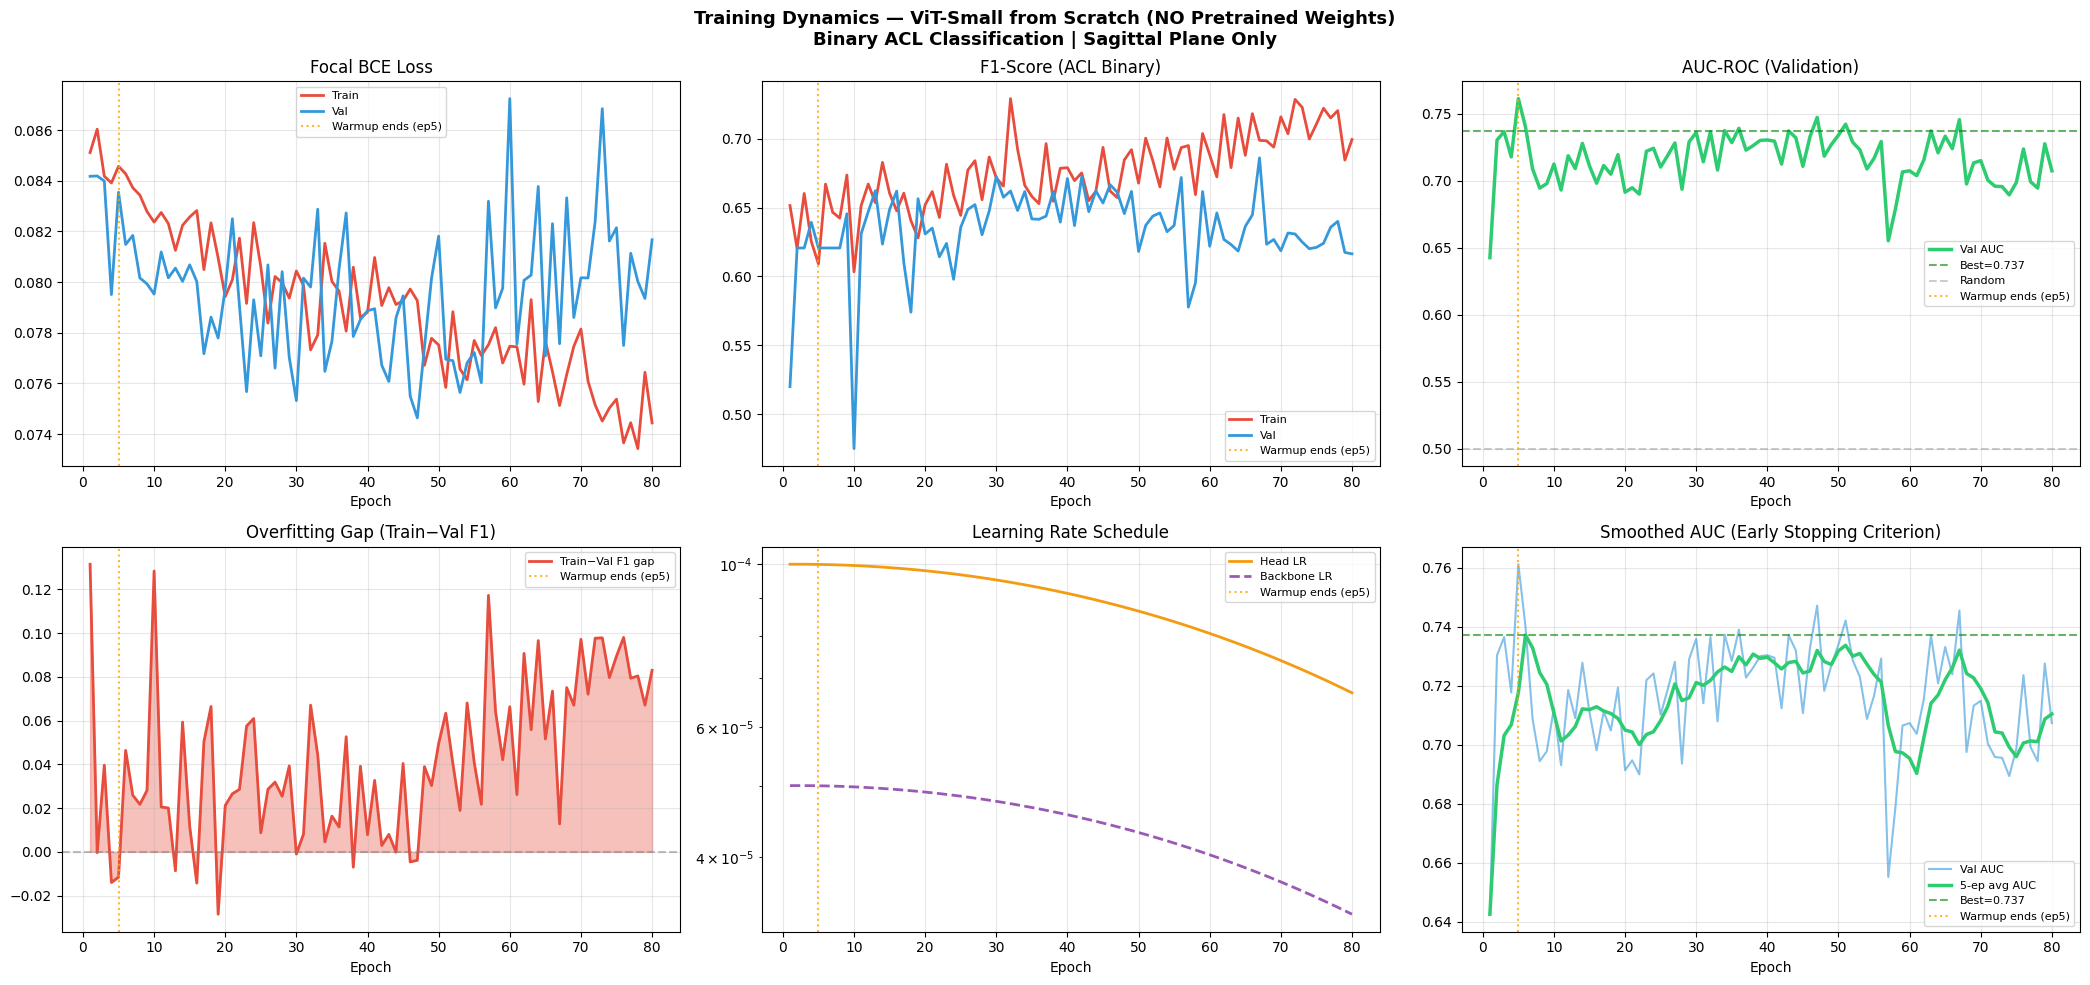

✓ Saved: training_curves.png


In [69]:
ep = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(21, 10))
fig.suptitle(
    f"Training Dynamics — ViT-Small from Scratch (NO Pretrained Weights)\n"
    f"Binary ACL Classification | Sagittal Plane Only",
    fontsize=13, fontweight="bold"
)

def add_warmup_line(ax):
    ax.axvline(CFG.WARMUP_EPOCHS, color="orange", linestyle=":", alpha=0.8, lw=1.5,
               label=f"Warmup ends (ep{CFG.WARMUP_EPOCHS})")

# Loss
axes[0,0].plot(ep, history["train_loss"], label="Train", color="#E74C3C", lw=2)
axes[0,0].plot(ep, history["val_loss"],   label="Val",   color="#3498DB", lw=2)
add_warmup_line(axes[0,0])
axes[0,0].set_title("Focal BCE Loss")
axes[0,0].legend(fontsize=8); axes[0,0].grid(alpha=0.3)

# F1
axes[0,1].plot(ep, history["train_f1"], label="Train", color="#E74C3C", lw=2)
axes[0,1].plot(ep, history["val_f1"],   label="Val",   color="#3498DB", lw=2)
add_warmup_line(axes[0,1])
axes[0,1].set_title("F1-Score (ACL Binary)")
axes[0,1].legend(fontsize=8); axes[0,1].grid(alpha=0.3)

# AUC-ROC
axes[0,2].plot(ep, history["val_auc"], label="Val AUC", color="#2ECC71", lw=2.5)
axes[0,2].axhline(best_val_auc, color="green", linestyle="--", alpha=0.6,
                   label=f"Best={best_val_auc:.3f}")
axes[0,2].axhline(0.5, color="gray", linestyle="--", alpha=0.4, label="Random")
add_warmup_line(axes[0,2])
axes[0,2].set_title("AUC-ROC (Validation)")
axes[0,2].legend(fontsize=8); axes[0,2].grid(alpha=0.3)

# Overfitting gap
gap = [t - v for t, v in zip(history["train_f1"], history["val_f1"])]
axes[1,0].fill_between(ep, 0, gap, alpha=0.35, color="#E74C3C")
axes[1,0].plot(ep, gap, color="#E74C3C", lw=2, label="Train−Val F1 gap")
axes[1,0].axhline(0, color="gray", linestyle="--", alpha=0.5)
add_warmup_line(axes[1,0])
axes[1,0].set_title("Overfitting Gap (Train−Val F1)")
axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

# LR schedule
axes[1,1].plot(ep, history["lr_head"],     label="Head LR",     color="#F39C12", lw=2)
axes[1,1].plot(ep, history["lr_backbone"], label="Backbone LR", color="#9B59B6", lw=2, linestyle="--")
add_warmup_line(axes[1,1])
axes[1,1].set_title("Learning Rate Schedule")
axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)
axes[1,1].set_yscale("log")

# Rolling AUC
roll_auc = pd.Series(history["val_auc"]).rolling(5, min_periods=1).mean()
axes[1,2].plot(ep, history["val_auc"], label="Val AUC",     color="#3498DB", lw=1.5, alpha=0.6)
axes[1,2].plot(ep, roll_auc,           label="5-ep avg AUC", color="#2ECC71", lw=2.5)
axes[1,2].axhline(best_val_auc, color="green", linestyle="--", alpha=0.6, label=f"Best={best_val_auc:.3f}")
add_warmup_line(axes[1,2])
axes[1,2].set_title("Smoothed AUC (Early Stopping Criterion)")
axes[1,2].legend(fontsize=8); axes[1,2].grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(CFG.OUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: training_curves.png")